W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,158 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
폰트 설정 완료 - NanumGothic 적용됨


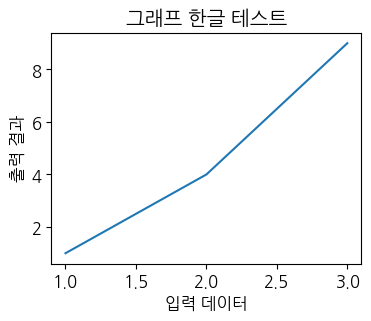

In [1]:
# 나눔고딕 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# Matplotlib 폰트 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import matplotlib

# 나눔고딕 폰트 경로 설정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic', size=12)

# 마이너스 폰트 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료 - NanumGothic 적용됨")


# ===== 테스트 그래프 =====
plt.figure(figsize=(4,3))
plt.title("그래프 한글 테스트")
plt.plot([1,2,3],[1,4,9])
plt.xlabel("입력 데이터")
plt.ylabel("출력 결과")
plt.show()

In [2]:
import torch
import torch.nn as nn

In [ ]:
'''
인코더 ↓↓
-------------------------------------
enc1 : 256 → 128   (채널 64)
enc2 : 128 →  64   (채널 128)
enc3 :  64 →  32   (채널 256)
enc4 :  32 →  16   (채널 512)
enc5 :  16 →   8   (채널 512)
enc6 :   8 →   4   (채널 512)
enc7 :   4 →   2   (채널 512)
enc8 :   2 →   1   (채널 512) ← 병목
-------------------------------------

디코더 ↑↑   (skip 연결)
-------------------------------------
dec1 : enc8 upsample → 2×2
        concat enc7 → (512 + 512)

dec2 : dec1 up → 4×4
        concat enc6 → (512 + 512)

dec3 : dec2 up → 8×8
        concat enc5 → (512 + 512)

dec4 : dec3 up → 16×16
        concat enc4 → (512 + 512)

dec5 : dec4 up → 32×32
        concat enc3 → (256 + 256)

dec6 : dec5 up → 64×64
        concat enc2 → (128 + 128)

dec7 : dec6 up → 128×128
        concat enc1 → (64 + 64)

dec8 : dec7 up → 256×256
-------------------------------------
'''

In [4]:
# U-Net 생성자(Generator) 클래스 정의
# 결론: skip connection 은 모든 up_conv_layer_X에 적용된다.
# 디코더에서 전체적인 맥락 유지, 인코더에서 (색상, 질감) 보존해서 복원 (스킵커넥션)
class UNetGenerator(nn.Module):
  def __init__(self, chnls_in=3, chnls_op=3):
    super(UNetGenerator, self).__init__()

  # 인코더(다운샘플링) 블록  >> 특징 추출
  # DownConvBlock 은 해상도를 줄이고 채널을 늘림
    self.down_conv_layer1 = nn.DownConvBlock(chnls_in, 64, norm=False)
    # 초기 블럭은 정규화 제외 (원본에 가깝게)
    self.down_conv_layer2 = nn.DownConvBlock(64, 128)
    self.down_conv_layer3 = nn.DownConvBlock(128, 256)
    # 깊은 레이어에는 채널은 유지(512) 드롭아웃 적용 하여 과적합 방지
    self.down_conv_layer4 = nn.DownConvBlock(256, 512, dropout=0.5)
    self.down_conv_layer5 = nn.DownConvBlock(512, 512, dropout=0.5)
    self.down_conv_layer6 = nn.DownConvBlock(512, 512, dropout=0.5)
    self.down_conv_layer7 = nn.DownConvBlock(512, 512, dropout=0.5)
    # 병목(bottle-neck) 부분 : 해상도 변경 없음. 정규화, 드랍아웃 비활성화/활성화 옵션 적용
    self.down_conv_layer8 = nn.DownConvBlock(512, 512, norm=False, dropout=0.5)

  # 디코더(업샘플링) 블록
  # UpConvBlock 은 해상도를 늘리고(2배씩) concat 해서 채널을 합치고 채널 수를 줄입니다.
  # skip-connection 통해 인코더 출력을 받음
  # UpConvBlock의 입력 채널 (이전 디코더의 출력 채널 + 해당 인코더 출력 채널)
  # 병목 특징(enc8) 시작

    self.up_conv_layer1 = nn.UpConvBlock(512,512, dropout=0.5)
    self.up_conv_layer2 = nn.UpConvBlock(1024,512, dropout=0.5)
    # 512(dec1) + 512(enc6) >> 1024 >> 1024를 받아서 512 출력
    self.up_conv_layer3 = nn.UpConvBlock(1024,512, dropout=0.5)
    self.up_conv_layer4 = nn.UpConvBlock(1024,256, dropout=0.5)
    # 이전 dec + skip-connection = 512+512 = 1024
    self.up_conv_layer5 = nn.UpConvBlock(512,128)
    # 이전 dec + skip-connection = 256+128
    self.up_conv_layer6 = nn.UpConvBlock(256,64)
    #128 + 64
    self.up_conv_layer7 = nn.UpConvBlock(128,64)
    # 64 + 64

    # 최종 출력 레이어 정의
    # 최종 해상도 복원하기 위한 업샘플링 레이어 정의
    self.upsample_layer = nn.Upsample(scale_factor=2)
    # 최종 합성곱 전에 패딩을 위한 레이어 정의
    self.zero_pad = nn.ZeroPad2d((1,0,1,0))
    # nn.ZeroPad2d((left, right, top, down)) px에 0으로 채워라

    # 최종 출력 채널(chnls_op)을 맞추기 위한 합성곱 레이어 정의
    self.conv_layer1 = nn.Conv2d(64, chnls_op, 4, padding=1)
    # 입력 채널 64, chnls_op 3(RGB), 4: kernel_size

    # 최종 출력 픽셀 값 [-1,1] 범위 제한 >> Tanh 활성화함수
    self.activation = nn.Tanh()

  # 데이터 순전파 정의
  def forward(self, x):
    # 인코딩 경로
    # 각 다운 샘플링 블록 통과 >> 출력 enc1 - enc8 에 저장(skip-connection)
    enc1 = self.down_conv_layer1(x)     # 가장 얇은 특징 (입력이미지와 해상동 유지)
    enc2 = self.down_conv_layer2(enc1)
    enc3 = self.down_conv_layer3(enc2)
    enc4 = self.down_conv_layer4(enc3)
    enc5 = self.down_conv_layer5(enc4)
    enc6 = self.down_conv_layer6(enc5)
    enc7 = self.down_conv_layer7(enc6)
    enc8 = self.down_conv_layer8(enc7)   # 병목(bottle-neck) 특징(해상도는 가장 낮아, 압축되어 있는 고수준 특징)
    # 채널 변화 enc1 64, enc2 128 enc3 256, enc4-enc8 512

    # 디코딩 경로(스킵 커넥션 포함)
    # 업샘플링 블록 통과 >> 이전 디코더 출력(decX)과 해당 인코더 출력(encY) 를 입력으로 받음
    dec1 = self.up_conv_layer1(enc8, enc7) # enc8(병목)이 디코딩의 시작, enc7 (스킵커넥션)
    dec2 = self.up_conv_layer2(dec1, enc6)
    dec3 = self.up_conv_layer3(dec2, enc5)
    dec4 = self.up_conv_layer4(dec3, enc4)
    dec5 = self.up_conv_layer5(dec4, enc3)
    dec6 = self.up_conv_layer6(dec5, enc2)
    dec7 = self.up_conv_layer7(dec6, enc1) # 인코딩 경로 가장 얕은 특징과 결합
    # dec7 : 해상도가 가장 높고 채널수는 가장 적어요(64채널)
    # dec1 = self.up_conv_layer1(enc8, enc7) # enc8(병목)이 디코딩의 시작, enc7 (스킵커넥션)
    # enc8(512)+enc7(512) = 1024 >> conv(1024)>> 512

    # dec1 = self.up_conv_layer1(enc8, enc7)
    # 총입력채널 (이전 dec: enc8 512. 스킵커넥션 enc7 512) 총입력채널 1024 출력 512
    # dec2 = self.up_conv_layer1(dec1, enc6)
    # 총입력채널 (이전 dec: dec1 512. 스킵커넥션 enc6 512) 총입력채널 1024 출력 512
    # dec3 = self.up_conv_layer1(dec2, enc5)
    # 총입력채널 (이전 dec: dec2 512. 스킵커넥션 enc5 512) 총입력채널 1024 출력 512
    # dec4 = self.up_conv_layer1(dec3, enc4)
    # 총입력채널 (이전 dec: dec3 512. 스킵커넥션 enc4 512) 총입력채널 1024 출력 256

    # dec5 = self.up_conv_layer1(dec4, enc3)
    # 총입력채널 (이전 dec: dec4 256, 스킵커넥션 enc3 256) 총입력채널 512 출력 128
    # dec6 = self.up_conv_layer1(dec5, enc2)
    # 총입력채널 (이전 dec: dec5 128, 스킵커넥션 enc2 128) 총입력채널 256 출력 64
    # dec7 = self.up_conv_layer1(dec6, enc3)
    # 총입력채널 (이전 dec: dec6 64, 스킵커넥션 enc1 64) 총입력채널 128 출력 64

    # 최종 출력
    # 마지막 디코더 출력(dec7)을 최종적으로 한번 더 업샘플링함
    final = self.upsample_layer(dec7)

    # 최종 합성곱을 위한 패딩 적용
    final = self.zero_pad(final)

    # 최종 합성곱 레이어 통과 >> 출력 채널
    final = self.conv_layer1(final)

    # Tanh 활성화 함수 통과 >> 최종 이미지 반환
    return self.activation(final)

- UpConvBlock에서 concat 후 conv 적용 시, 입력 채널 수는 이전 디코더 출력 + 스킵 연결 출력
- dec1~dec4는 concat 후 conv 없이 그대로 512 출력 유지 (혹은 conv로 채널 정규화 가능)
- dec5~dec7은 concat 후 conv에서 출력 채널 수를 줄여 디코더 점점 얕아지는 구조

| 단계   | 이전 디코더 출력 | 인코더 스킵 출력 | concat 입력(channel) | 출력  |
| ---- | --------- | --------- | ------------------ | --- |
| dec1 | 512       | 512       | 1024               | 512 |
| dec2 | 512       | 512       | 1024               | 512 |
| dec3 | 512       | 512       | 1024               | 512 |
| dec4 | 512       | 512       | 1024               | 512 |
| dec5 | 512       | 256       | 768                | 256 |
| dec6 | 256       | 128       | 384                | 128 |
| dec7 | 128       | 64        | 192                | 64  |


In [ ]:
# U-Net의 업샘플링 합성곱 블록 클래스를 정의함.
class UpConvBlock(nn.Module):
    # 모듈 초기화. ip_sz: 입력 채널, op_sz: 출력 채널, dropout: 드롭아웃 확률을 받음.
    def __init__(self, ip_sz, op_sz, dropout=0.0):
        super(UpConvBlock, self).__init__()

        # 블록을 구성할 레이어 리스트를 정의함.
        self.layers = [
            # 전치 합성곱(ConvTranspose2d)을 사용해 업샘플링함. 커널 4, 스트라이드 2, 패딩 1로 해상도를 2배로 높임.
            nn.ConvTranspose2d(ip_sz, op_sz, 4, 2, 1),
            # 배치 정규화 대신 인스턴스 정규화(InstanceNorm2d)를 적용함. (Pix2Pix GAN에서 흔히 사용됨)
            # 배치 전체가 아닌 개별 샘플(instance)를 정규화
            nn.InstanceNorm2d(op_sz),
            # ReLU 활성화 함수를 적용함.
            nn.ReLU(),
        ]

        # 드롭아웃 확률이 0.0보다 크면 드롭아웃 레이어를 추가함.
        if dropout:
            self.layers += [nn.Dropout(dropout)]

    # 순전파 함수를 정의함. x: 이전 디코더 출력, enc_ip: 스킵 커넥션으로 받은 인코더 출력을 입력받음.
    def forward(self, x, enc_ip):
        # 정의된 레이어들을 nn.Sequential로 묶어 x를 통과시킴.
        x = nn.Sequential(*(self.layers))(x)

        # 업샘플링된 결과(x)와 해당 인코더 출력(enc_ip)(특징맵)을 채널 차원(1번)을 따라 결합(concatenate)함.
        # 채널 기준으로 쌓는다
        op = torch.cat((x, enc_ip), 1)

        # 결합된 특징 맵을 반환함. (디코더 블록의 입력)
        return op

In [ ]:
# U-Net의 다운샘플링 합성곱 블록 클래스를 정의함.
class DownConvBlock(nn.Module):
    # 모듈 초기화. ip_sz: 입력 채널, op_sz: 출력 채널, norm: 정규화 사용 여부, dropout: 드롭아웃 확률을 받음.
    def __init__(self, ip_sz, op_sz, norm=True, dropout=0.0):
        super(DownConvBlock, self).__init__()

        # 첫 번째 레이어: 4x4 합성곱을 정의함. stride=2, padding=1로 해상도를 절반으로 줄임. 채널 증가
        self.layers = [nn.Conv2d(ip_sz, op_sz, 4, 2, 1)]

        # 정규화(norm)가 True인 경우 인스턴스 정규화 레이어를 추가함. 채널 증가
        if norm:
            self.layers.append(nn.InstanceNorm2d(op_sz))

        # Leaky ReLU 활성화 함수를 추가함.
        self.layers += [nn.LeakyReLU(0.2)]
        # 음수값에 대해 0.2 기울기 허용

        # 드롭아웃 확률이 0.0보다 큰 경우 드롭아웃 레이어를 추가함.
        if dropout:
            self.layers += [nn.Dropout(dropout)]

    # 순전파 함수를 정의함.
    def forward(self, x):
        # 정의된 레이어들을 nn.Sequential로 묶어 x를 통과시킴.
        op = nn.Sequential(*(self.layers))(x)

        # 최종 특징 맵(op)을 반환함.
        return op

In [ ]:
# Pix2Pix 판별자 클래스를 정의함.
class Pix2PixDiscriminator(nn.Module):
    # 모델의 레이어들을 정의하여 초기화함. chnls_in: 입력 이미지 채널 수를 받음.
    def __init__(self, chnls_in=3):
        super(Pix2PixDiscriminator, self).__init__()

        # 합성곱, 정규화, 활성화 함수로 구성된 판별 블록을 정의하는 헬퍼 함수임.
        def disc_conv_block(chnls_in, chnls_op, norm=1):
            # 4x4 합성곱, stride=2, padding=1로 해상도를 절반으로 줄임.
            layers = [nn.Conv2d(chnls_in, chnls_op, 4, stride=2, padding=1)]

            # 정규화(norm)가 True인 경우 인스턴스 정규화 레이어를 추가함.
            if normalization: # 'normalization' 변수가 클래스 외부에서 정의되었다고 가정함.
                layers.append(nn.InstanceNorm2d(chnls_op))

            # Leaky ReLU 활성화 함수를 추가함.
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # 첫 번째 레이어(lyr1): 입력 이미지(실제 + 생성)를 결합하므로 채널은 chnls_in * 2임.
        # 정규화는 사용하지 않음(norm=0).
        self.lyr1 = disc_conv_block(chnls_in * 2, 64, norm=0)
        # 두 번째 레이어(lyr2): 64채널을 128채널로 변환함.
        self.lyr2 = disc_conv_block(64, 128)
        # 세 번째 레이어(lyr3): 128채널을 256채널로 변환함.
        self.lyr3 = disc_conv_block(128, 256)
        # 네 번째 레이어(lyr4): 256채널을 512채널로 변환함.
        self.lyr4 = disc_conv_block(256, 512)

    # 데이터의 순전파 경로를 정의함.
    def forward(self, real_image, translated_image):
        # 실제 이미지와 생성된 이미지를 채널 차원(1번)을 따라 결합하여 입력(ip)을 만듦.
        # Pix2Pix 조건부 GAN
        ip = torch.cat((real_image, translated_image), 1)

        # 합성곱 블록들을 순서대로 통과시킴.
        # 해상도는 점진적으로 줄어들어요(다운샘플링)>>채널은 늘어남
        op = self.lyr1(ip)
        op = self.lyr2(op)
        op = self.lyr3(op)
        op = self.lyr4(op)

        # 최종 합성곱 레이어 전 패딩을 적용함.
        op = nn.ZeroPad2d((1, 0, 1, 0))(op)
        # 최종 512채널을 1채널 출력으로 변환하는 합성곱 레이어를 통과시킴.
        op = nn.Conv2d(512, 1, 4, padding=1)(op)

        # 최종 패치별 진위 여부 예측 맵을 반환함. (Sigmoid는 외부에서 적용될 수 있음)
        return op

pix2pix 실습

In [5]:
import torch                          # 파이토치 기본 모듈을 불러옴
import torch.nn as nn                 # 신경망 레이어를 제공하는 nn 모듈을 불러옴
import torch.nn.functional as F       # 보조 함수들(ReLU, interpolate 등)을 제공하는 F 모듈을 불러옴
from torch.utils.data import DataLoader, Subset  # 미니배치 생성을 위한 DataLoader와 Subset을 불러옴

import torchvision                    # 토치비전(이미지용 데이터셋/모듈)을 불러옴
import torchvision.transforms as T    # 이미지 변환을 위한 transforms 모듈을 불러옴

import matplotlib.pyplot as plt       # 시각화를 위한 matplotlib.pyplot을 불러옴
import numpy as np                   # 텐서를 넘파이로 바꿔서 그림에 쓰기 위해 numpy를 불러옴

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda, 없으면 cpu를 선택함
print("사용 중인 device:", device)                                     # 현재 선택된 device를 출력함

사용 중인 device: cpu
